In [50]:
import math
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import os
import scipy.sparse as sp

from reaction_diffusion.routines.tomo_fusion.tools import plotting_fcts as tomo_plots

<Figure size 640x480 with 0 Axes>

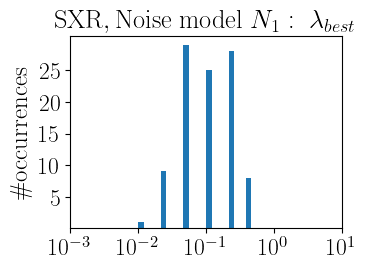

In [64]:
best_hyper = np.load("tuning_data/reg_param_tuning_sigma002/best_hyperparams.npy", allow_pickle=True)
nb_occurrences = np.load("tuning_data/reg_param_tuning_sigma002/nb_occurrences.npy", allow_pickle=True)

plt.figure()

plt.figure(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})


vec = np.zeros(100)
counter=0
for i in range(13):
    vec[counter:counter+int(nb_occurrences[i])] = i
    counter += int(nb_occurrences[i])

plt.hist(vec, bins=20)
plt.xticks([0,3,6,9,12], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"], fontsize=17)
plt.yticks([5,10,15,20,25], fontsize=17) 
plt.title(r"$\mathrm{SXR, Noise \;model \;}N_1:\;\lambda_{best}$", fontsize=19)

plt.ylabel(r"$\# \mathrm{occurrences}$", fontsize=18, labelpad=5)

plt.show()

In [67]:
tffacsxr = np.load("tuning_data/reg_param_tuning_sxr/factors_avg_wrt_best.npy", allow_pickle=True)
ttffacsxr001 = np.load("tuning_data/reg_param_tuning_sxr/factors_001_wrt_best.npy", allow_pickle=True)
# plt.plot(tffacsxr.flatten(), '.')
# plt.show()
# plt.plot(ttffacsxr001.flatten(), '.')
# plt.show()
print("mean factor for SXR:", np.mean(tffacsxr))
print("mean factor for SXR with reg param fixed to 1e-1:", np.mean(ttffacsxr001))

mean factor for SXR: 1.2195864535600547
mean factor for SXR with reg param fixed to 1e-1: 1.164851373788752


<Figure size 640x480 with 0 Axes>

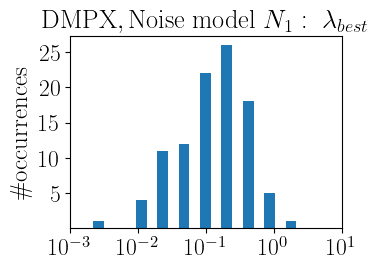

In [68]:
best_hyper = np.load("tuning_data/reg_param_tuning_dmpx/best_hyperparams.npy", allow_pickle=True)
nb_occurrences = np.load("tuning_data/reg_param_tuning_dmpx/nb_occurrences.npy", allow_pickle=True)

plt.figure()

plt.figure(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})


vec = np.zeros(100)
counter=0
for i in range(13):
    vec[counter:counter+int(nb_occurrences[i])] = i
    counter += int(nb_occurrences[i])

plt.hist(vec, bins=19)
plt.xticks([0,3,6,9,12], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"], fontsize=17)
plt.yticks([5,10,15,20,25], fontsize=17) 
plt.title(r"$\mathrm{DMPX, Noise \;model \;}N_1:\;\lambda_{best}$", fontsize=19)

plt.ylabel(r"$\# \mathrm{occurrences}$", fontsize=18, labelpad=5)

plt.show()

In [69]:
td=np.load("tuning_data/reg_param_tuning_dmpx/tuning_data.npy", allow_pickle=True)
tffac = np.load("tuning_data/reg_param_tuning_dmpx/factors_avg_wrt_best.npy", allow_pickle=True)
tffac001 = np.load("tuning_data/reg_param_tuning_dmpx/factors_001_wrt_best.npy", allow_pickle=True)
rpmean=np.load("tuning_data/reg_param_tuning_dmpx/reg_param_mean.npy", allow_pickle=True)
rpmedian=np.load("tuning_data/reg_param_tuning_dmpx/reg_param_median.npy", allow_pickle=True)
print("mean,median", rpmean, rpmedian)
print("factors", np.mean(tffac), np.mean(tffac001))

# could use 2e-2 maybe... or neglect this thing and who cares, try without first?

mean,median 0.24146957695244853 0.1577217345015941
factors 1.1994348924574725 1.1717565239337757


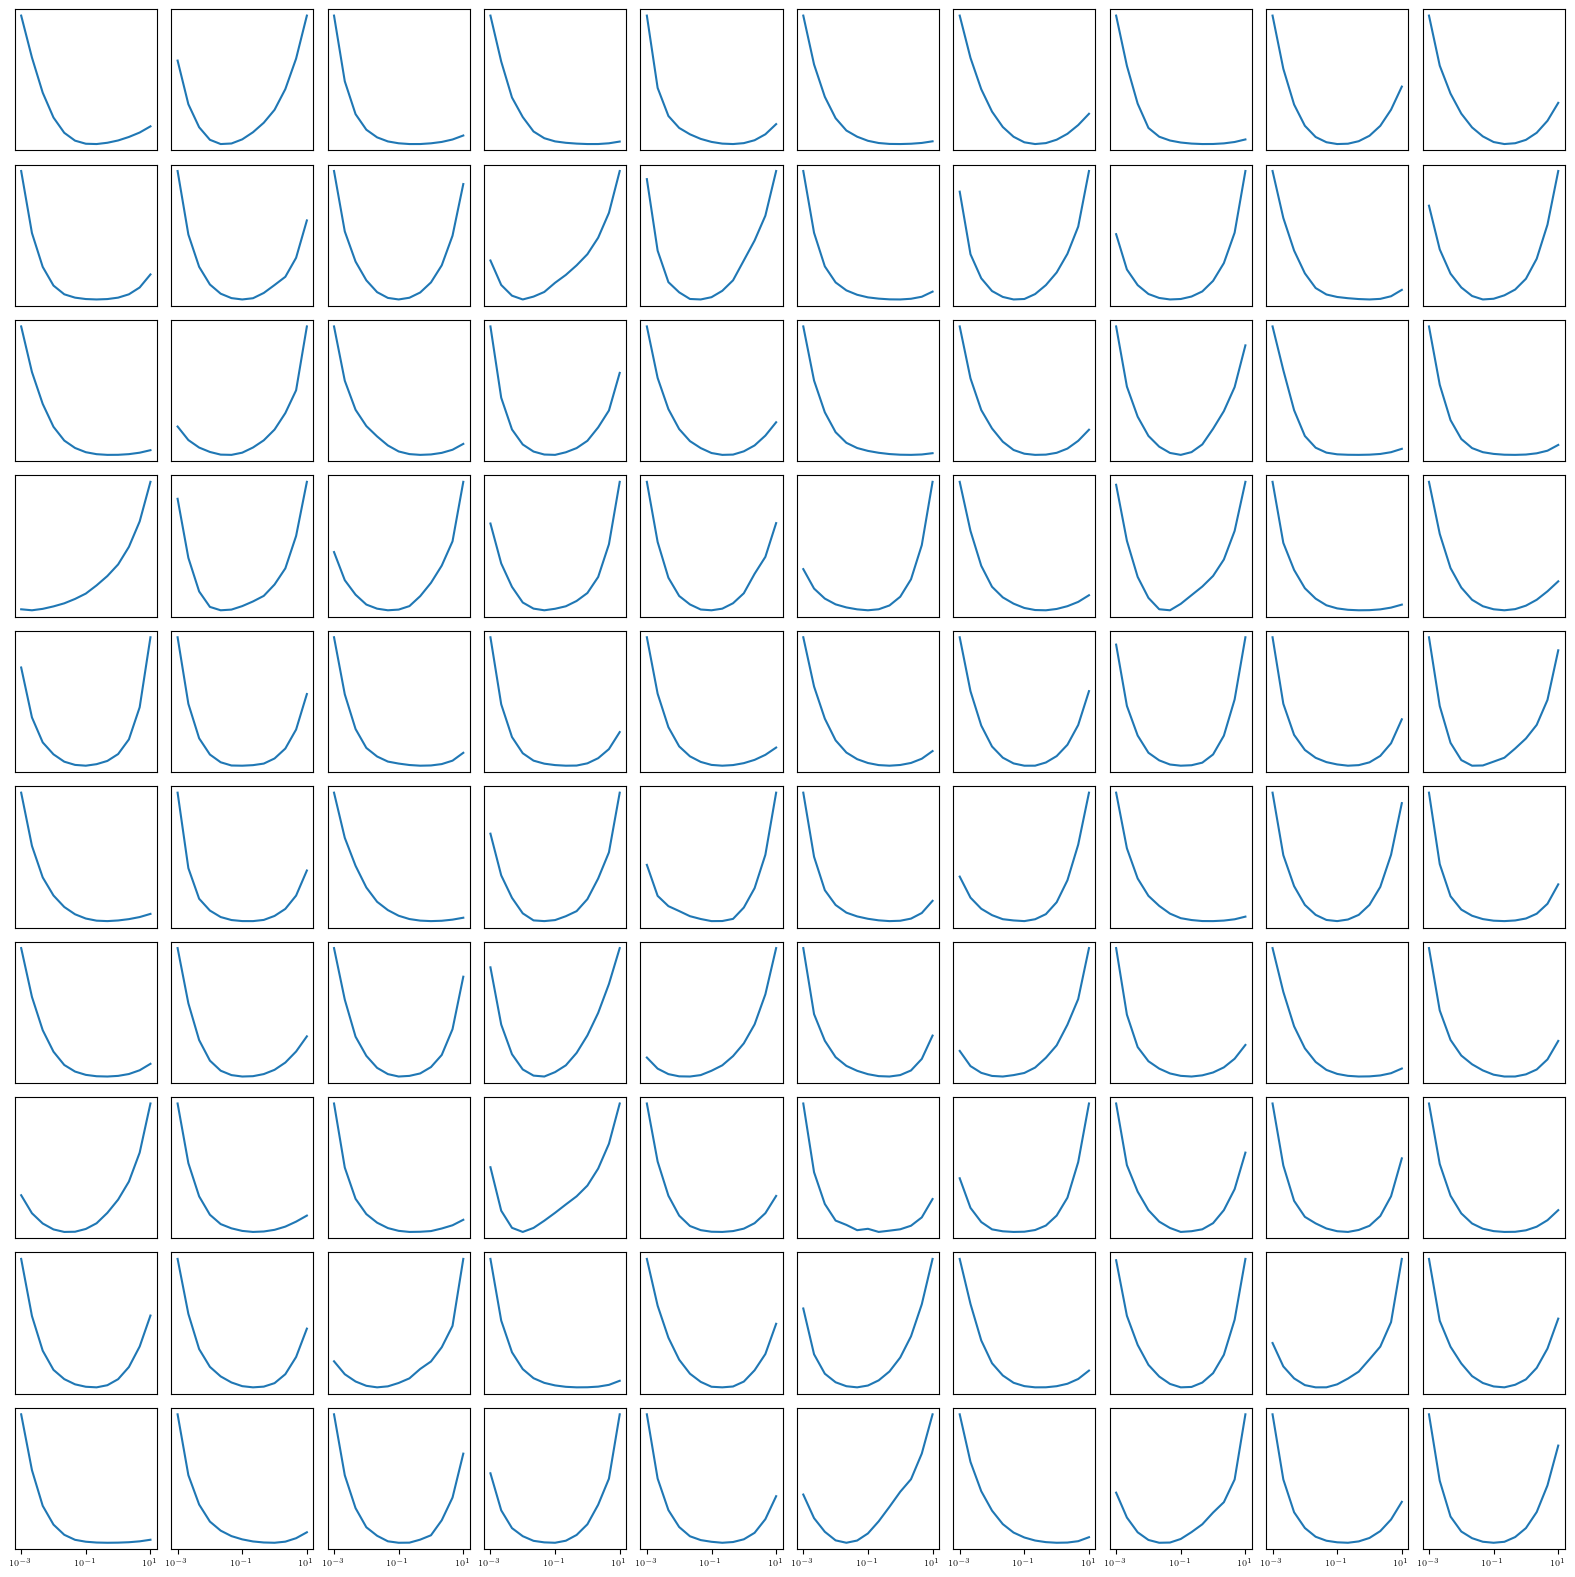

In [38]:
# create 10x10 plot of td[i]['GT'][2,:], i=1,...,100
plt.figure(figsize=(20,20))
plt.subplots_adjust(wspace=0.1, hspace=0.1)
for i in range(100):
    plt.subplot(10,10,i+1)
    plt.plot(td[i]['GT'][2,:])
    if i>=90:
        plt.xticks([0,6,12], [r"$10^{-3}$", r"$10^{-1}$", r"$10^{1}$"], fontsize=6)
    else:
        plt.xticks([])
    plt.yticks([])
plt.show()  

#plt.plot(td[0]['GT'][2,:])


<Figure size 640x480 with 0 Axes>

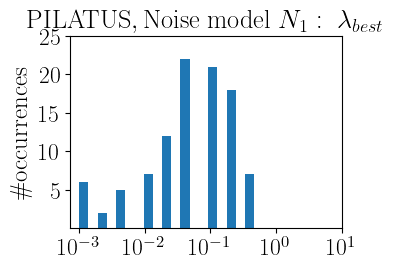

In [70]:
best_hyper = np.load("tuning_data/reg_param_tuning_pilatus/best_hyperparams.npy", allow_pickle=True)
nb_occurrences = np.load("tuning_data/reg_param_tuning_pilatus/nb_occurrences.npy", allow_pickle=True)

plt.figure()

plt.figure(figsize=(3.5,2.5))
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
})


vec = np.zeros(100)
counter=0
for i in range(13):
    vec[counter:counter+int(nb_occurrences[i])] = i
    counter += int(nb_occurrences[i])

plt.hist(vec, bins=19)
plt.xticks([0,3,6,9,12], [r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", r"$10^{0}$", r"$10^{1}$"], fontsize=17)
plt.yticks([5,10,15,20,25], fontsize=17) 
plt.title(r"$\mathrm{PILATUS, Noise \;model \;}N_1:\;\lambda_{best}$", fontsize=19)

plt.ylabel(r"$\# \mathrm{occurrences}$", fontsize=18, labelpad=5)

plt.show()

In [ ]:
td=np.load("tuning_data/reg_param_tuning_pilatus/tuning_data.npy", allow_pickle=True)
tffac = np.load("tuning_data/reg_param_tuning_pilatus/factors_avg_wrt_best.npy", allow_pickle=True)
tffac001 = np.load("tuning_data/reg_param_tuning_pilatus/factors_001_wrt_best.npy", allow_pickle=True)
rpmean=np.load("tuning_data/reg_param_tuning_pilatus/reg_param_mean.npy", allow_pickle=True)
rpmedian=np.load("tuning_data/reg_param_tuning_pilatus/reg_param_median.npy", allow_pickle=True)
print("mean,median", rpmean, rpmedian)
print("factors", np.mean(tffac), np.mean(tffac001))

# could use 2e-2 maybe... or neglect this thing and who cares, try without first?

mean,median 0.106102931453331 0.046415888336127774
factors 1.0394654029381243 1.0396136381070182


In [60]:
nb_occurrences

array([73.,  7.,  7.,  4.,  7.,  1.,  1.,  0.,  0.,  0.,  0.,  0.,  0.])

In [61]:
np.logspace(-5, -1, 13)

array([1.00000000e-05, 2.15443469e-05, 4.64158883e-05, 1.00000000e-04,
       2.15443469e-04, 4.64158883e-04, 1.00000000e-03, 2.15443469e-03,
       4.64158883e-03, 1.00000000e-02, 2.15443469e-02, 4.64158883e-02,
       1.00000000e-01])

In [63]:
np.logspace(-5, 1, 19)

array([1.00000000e-05, 2.15443469e-05, 4.64158883e-05, 1.00000000e-04,
       2.15443469e-04, 4.64158883e-04, 1.00000000e-03, 2.15443469e-03,
       4.64158883e-03, 1.00000000e-02, 2.15443469e-02, 4.64158883e-02,
       1.00000000e-01, 2.15443469e-01, 4.64158883e-01, 1.00000000e+00,
       2.15443469e+00, 4.64158883e+00, 1.00000000e+01])